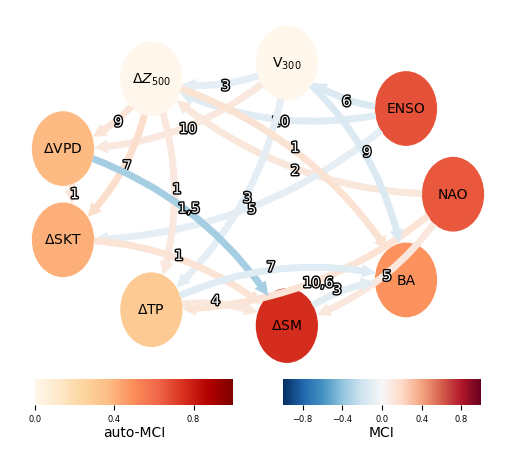

In [8]:
# =============================================================================
# PCMCI Causal Graph Analysis
# =============================================================================

from pathlib import Path
import copy
import json

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation
import pandas as pd
import numpy as np

# Tigramite data processing and plotting
from tigramite import data_processing as pp
from tigramite import plotting as tp

# Causal-discovery methods
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.pcmci import PCMCI

# Optional graph analysis
import networkx as nx


# =============================================================================
# Repository paths
# =============================================================================

# This assumes the notebook is run from the Code directory.
PROJECT_DIR = Path.cwd().parent

DATASET_DIR = PROJECT_DIR / "Dataset"
OUTPUT_DIR = PROJECT_DIR / "Output"
FIGURE_DIR = OUTPUT_DIR / "Figures"
RESULT_DIR = OUTPUT_DIR / "Results"

CSV_FILE = DATASET_DIR / "PCMIC_India_20112021_withNAO_withV.csv"
GRAPH_FILE = FIGURE_DIR / "pcmci_SEA_JSTAR.png"

VAL_MATRIX_FILE = RESULT_DIR / "pcmci_val_matrix.npy"
P_MATRIX_FILE = RESULT_DIR / "pcmci_p_matrix.npy"
GRAPH_MATRIX_FILE = RESULT_DIR / "pcmci_graph.npy"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# Validate the input file
# =============================================================================

if not CSV_FILE.exists():
    raise FileNotFoundError(
        f"Input CSV file was not found:\n{CSV_FILE}\n\n"
        "Place PCMIC_India_20112021_withNAO_withV.csv inside the Dataset folder."
    )


# =============================================================================
# Load and prepare data
# =============================================================================

data_df = pd.read_csv(CSV_FILE, index_col="date")
data_df.index = pd.to_datetime(data_df.index)

print("Input file:", CSV_FILE)
print("Data shape:", data_df.shape)
print("\nColumns:")
print(list(data_df.columns))
print("\nDate range:")
print(data_df.index.min(), "to", data_df.index.max())


# Rename selected variables for plotting
column_rename_map = {
    "v": r"$\mathrm{V_{300}}$",
    "Z_an": r"$\Delta Z_{500}$",
    "VPD_an": r"$\Delta \mathrm{VPD}$",
    "SKT_an": r"$\Delta \mathrm{SKT}$",
    "TP_an": r"$\Delta \mathrm{TP}$",
    "SM_an": r"$\Delta \mathrm{SM}$",
}

data_df.rename(columns=column_rename_map, inplace=True)

tig_df = pp.DataFrame(
    data_df.to_numpy(),
    var_names=list(data_df.columns),
    missing_flag=999.0,
)


# =============================================================================
# Diagnostic plots
# =============================================================================

def plot_timeseries_and_correlations(
    dataframe: pp.DataFrame,
    tau_max: int = 10,
) -> None:
    """
    Plot the input time series, scatter plots, and lagged dependencies.

    Parameters
    ----------
    dataframe
        Tigramite dataframe.
    tau_max
        Maximum time lag used for lagged-dependency diagnostics.
    """

    tp.plot_timeseries(
        dataframe,
        figsize=(8, 7),
        grey_masked_samples="data",
    )

    parcorr = ParCorr(significance="analytic")

    diagnostic_pcmci = PCMCI(
        dataframe=dataframe,
        cond_ind_test=parcorr,
        verbosity=1,
    )

    dependency_results = diagnostic_pcmci.get_lagged_dependencies(
        tau_max=tau_max,
        val_only=True,
    )

    correlations = dependency_results["val_matrix"]

    tp.plot_scatterplots(
        dataframe=dataframe,
        add_scatterplot_args={"matrix_lags": None},
    )

    tp.plot_lagfuncs(
        val_matrix=correlations,
        setup_args={
            "var_names": dataframe.var_names,
            "x_base": 5,
            "y_base": 0.5,
        },
    )

    plt.show()


plot_timeseries_and_correlations(tig_df, tau_max=10)


# =============================================================================
# PCMCI settings
# =============================================================================

tau_min = 1
tau_max = 10
pc_alpha = None
alpha_level = 0.01

number_of_variables = len(tig_df.var_names)

print("Number of variables:", number_of_variables)

if number_of_variables < 9:
    raise ValueError(
        "This analysis uses variable indices from 0 to 8, but the input "
        f"contains only {number_of_variables} variables."
    )


# =============================================================================
# Link assumptions
# =============================================================================

link_assumptions = {
    target: {
        (source, -lag): "o?o"
        for source in range(number_of_variables)
        for lag in range(tau_min, tau_max + 1)
    }
    for target in range(number_of_variables)
}


def remove_link(
    assumptions: dict,
    target: int,
    source: int,
    lag: int,
) -> None:
    """
    Remove a candidate source-to-target link when it exists.
    """

    key = (source, -lag)

    if key in assumptions[target]:
        del assumptions[target][key]
        print(
            f"Removed candidate link: source={source}, "
            f"target={target}, lag={lag}"
        )


def force_directed_link(
    assumptions: dict,
    target: int,
    source: int,
    lag: int,
) -> None:
    """
    Force a directed source-to-target link at the selected lag.
    """

    assumptions[target][(source, -lag)] = "-->"


# Candidate links excluded from the analysis
excluded_links = [
    # target, source, lag
    (2, 8, 9),
    (1, 5, 3),
    (3, 8, 1),
    (0, 6, 9),
    (0, 7, 7),
    (7, 8, 10),
    (3, 4, 4),
    (3, 5, 1),
    (3, 6, 1),
    (3, 6, 3),
    (8, 7, 4),
    (4, 6, 4),
]

for target, source, lag in excluded_links:
    remove_link(
        assumptions=link_assumptions,
        target=target,
        source=source,
        lag=lag,
    )


# Directed links imposed as prior assumptions
forced_links = [
    # target, source, lag
    (8, 3, 1),
    (3, 0, 2),
    (3, 2, 3),
    (5, 1, 5),
    (8, 6, 7),
    (6, 2, 3),
    (8, 7, 3),
    (3, 1, 10),
    (6, 3, 1),
    (7, 6, 4),
    (4, 2, 10),
    (8, 2, 9),
    (2, 1, 6),
    (6, 0, 6),
    (7, 0, 5),
]

for target, source, lag in forced_links:
    force_directed_link(
        assumptions=link_assumptions,
        target=target,
        source=source,
        lag=lag,
    )


# =============================================================================
# Run PCMCI
# =============================================================================

robust_parcorr = RobustParCorr()

pcmci = PCMCI(
    dataframe=tig_df,
    cond_ind_test=robust_parcorr,
    verbosity=1,
)

pcmci_results = pcmci.run_pcmci(
    tau_min=tau_min,
    tau_max=tau_max,
    pc_alpha=pc_alpha,
    alpha_level=alpha_level,
    link_assumptions=link_assumptions,
)


# =============================================================================
# Manual MCI-value overrides
# =============================================================================
#
# These values reproduce the graph configuration used for the publication.
# Keep this section documented because these values overwrite values returned
# directly by the PCMCI calculation.
# =============================================================================

manual_mci_values = [
    # source, target, lag, MCI value
    (3, 8, 1, 0.14559938),
    (0, 3, 2, 0.11305367),
    (2, 3, 3, -0.09882776),
    (1, 5, 5, -0.10066957),
    (6, 8, 7, -0.11840720),
    (2, 6, 3, -0.09642165),
    (7, 8, 3, -0.11653201),
    (1, 3, 10, -0.12130455),
    (3, 6, 1, 0.10195340),
    (6, 7, 4, 0.11703352),
    (2, 4, 10, 0.10683294),
    (2, 8, 9, -0.14769758),
    (1, 2, 6, -0.14769758),
    (0, 6, 6, 0.11919991),
    (0, 7, 5, 0.10584831),
]

for source, target, lag, value in manual_mci_values:
    pcmci_results["val_matrix"][source, target, lag] = value


# =============================================================================
# Save numerical PCMCI results
# =============================================================================

np.save(
    VAL_MATRIX_FILE,
    pcmci_results["val_matrix"],
)

if "p_matrix" in pcmci_results:
    np.save(
        P_MATRIX_FILE,
        pcmci_results["p_matrix"],
    )

np.save(
    GRAPH_MATRIX_FILE,
    pcmci_results["graph"],
)

print("Saved value matrix:", VAL_MATRIX_FILE)
print("Saved graph matrix:", GRAPH_MATRIX_FILE)


# =============================================================================
# Plot causal graph
# =============================================================================

vmin_nodes = 0
vmax_nodes = 1
cmap_nodes = "OrRd"

plt.figure(figsize=(12, 10))

tp.plot_graph(
    graph=pcmci_results["graph"],
    val_matrix=pcmci_results["val_matrix"],
    var_names=tig_df.var_names,
    node_size=0.55,
    node_aspect=0.55,
    arrow_linewidth=5.0,
    cmap_nodes=cmap_nodes,
    vmin_nodes=vmin_nodes,
    vmax_nodes=vmax_nodes,
    link_colorbar_label="MCI",
    node_colorbar_label="auto-MCI",
    arrowhead_size=20,
    curved_radius=0.2,
    show_colorbar=True,
)

plt.savefig(
    GRAPH_FILE,
    dpi=300,
    bbox_inches="tight",
)

print(f"Causal graph saved to:\n{GRAPH_FILE}")

plt.show()